<div style='color:rgb(0, 0, 0);
           background-color:rgb(240, 186, 8);
           font-size: 200%;
           border-radius:15px;
           text-align:center;
           font-weight:600;
           border-style: solid;
           border-color: dark green;
           font-family: "Cambria";'>
Projet: Tips ...
<a class="anchor" id="1"></a> 

In [1]:
import seaborn as sns
sns.set_theme(style="ticks", color_codes=True)
tips = sns.load_dataset("tips")


![](../../imgs/featureEngin.png)

In [2]:
tips.keys()

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [3]:
tips.head(3)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


In [4]:
tips.shape

(244, 7)

In [5]:
tips.smoker.unique()

['No', 'Yes']
Categories (2, object): ['Yes', 'No']

In [6]:
tips.time.unique()

['Dinner', 'Lunch']
Categories (2, object): ['Lunch', 'Dinner']

In [7]:
tips.time.nunique()

2

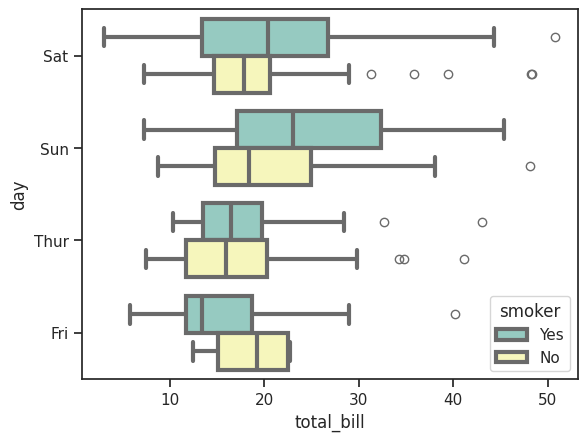

In [8]:
ax = sns.boxplot(y="day", x="total_bill",
                 hue="smoker",data=tips, palette="Set3", linewidth=3,
                order=["Sat", "Sun", "Thur", "Fri"], orient="h")

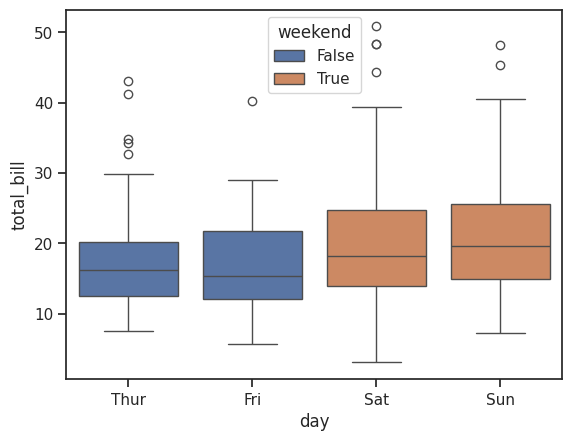

In [9]:
tips["weekend"] = tips["day"].isin(["Sat", "Sun"])
ax = sns.boxplot(x="day", y="total_bill", hue="weekend",
           data=tips, dodge=False)

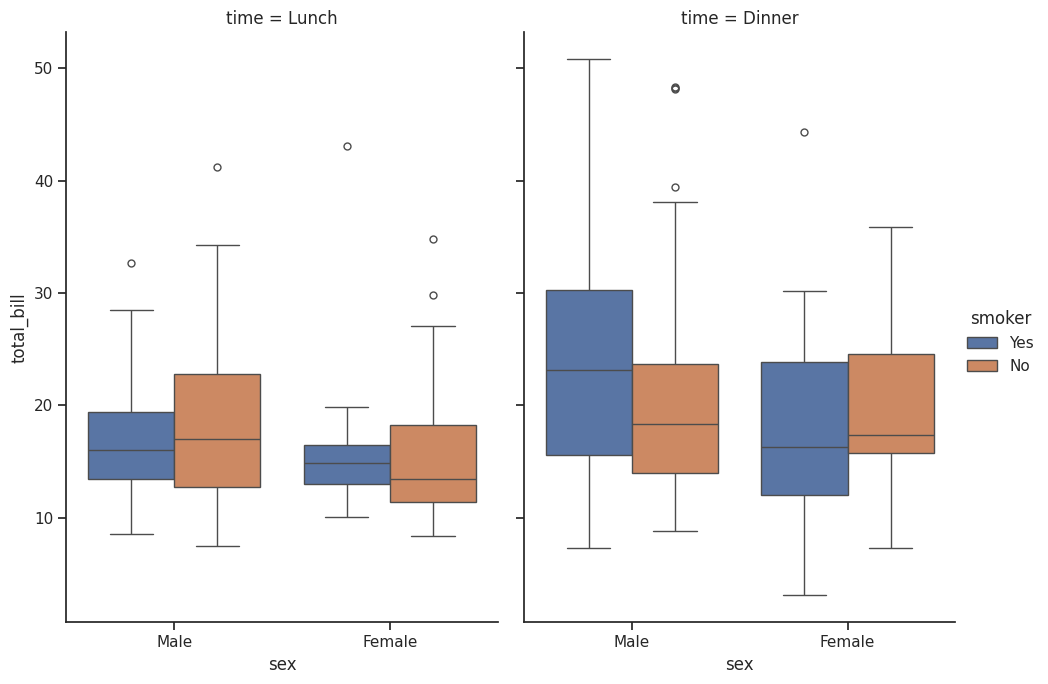

In [10]:
g = sns.catplot(x="sex", y="total_bill",
             hue="smoker", col="time",
             data=tips, kind="box",
             height=7, aspect=.7);

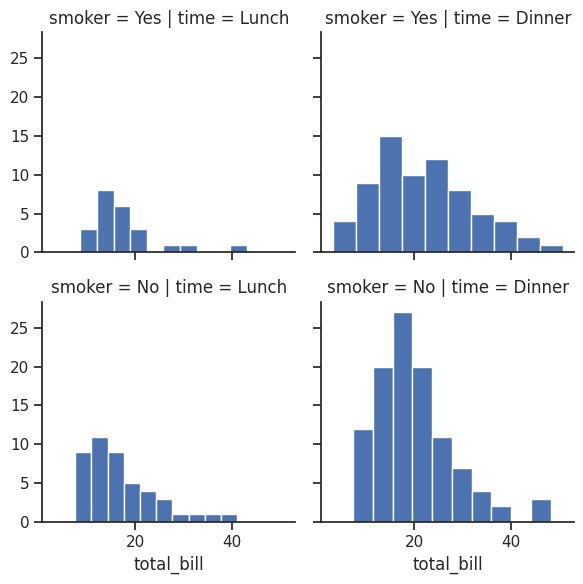

In [11]:
#Draw a univariate plot on each facet:
import matplotlib.pyplot as plt
g = sns.FacetGrid(tips, col="time", row="smoker")
g = g.map(plt.hist, "total_bill")

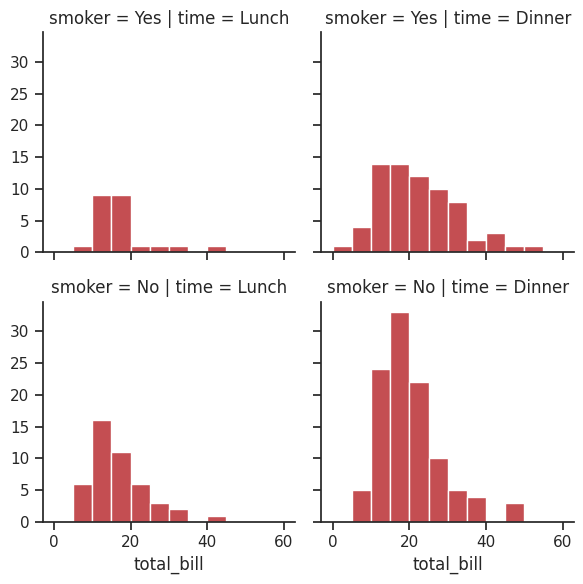

In [12]:
# Pass additional keyword arguments to the mapped function:
import numpy as np
bins = np.arange(0, 65, 5)
g = sns.FacetGrid(tips, col="time",  row="smoker")
g = g.map(plt.hist, "total_bill", bins=bins, color="r")


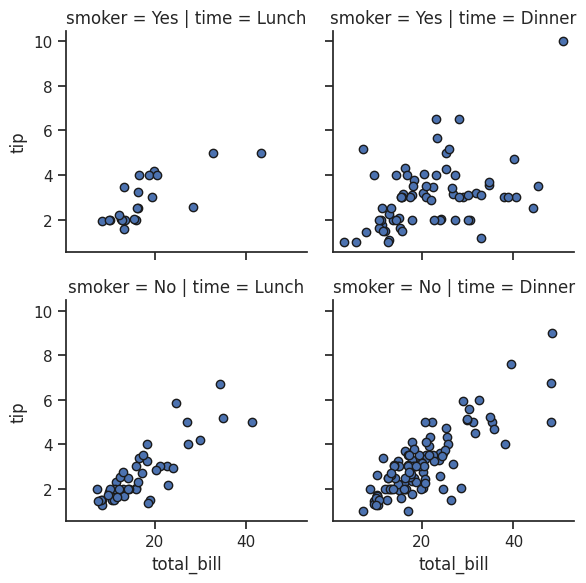

In [13]:
#Plot a bivariate function on each facet:#Plot a bivariate function on each facet:
g = sns.FacetGrid(tips, col="time",  row="smoker")
g = g.map(plt.scatter, "total_bill", "tip", edgecolor="k")

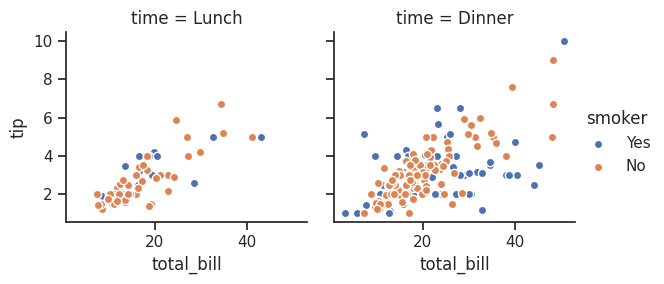

In [14]:
# Assign one of the variables to the color of the plot elements:
g = sns.FacetGrid(tips, col="time",  hue="smoker")
g = (g.map(plt.scatter, "total_bill", "tip", edgecolor="w").add_legend())

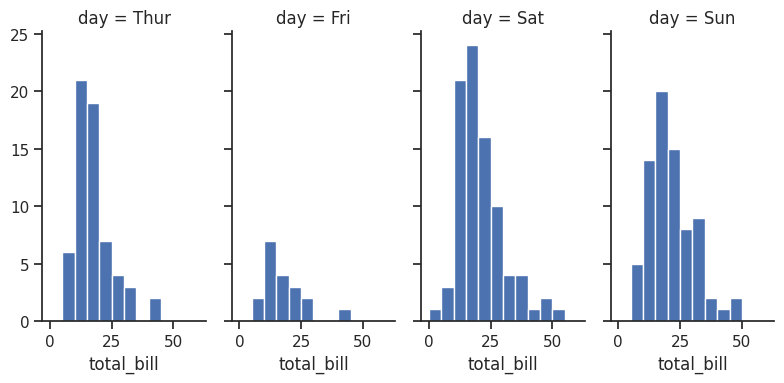

In [15]:
# Change the height and aspect ratio of each facet:
g = sns.FacetGrid(tips, col="day", height=4, aspect=.5)
g = g.map(plt.hist, "total_bill", bins=bins)

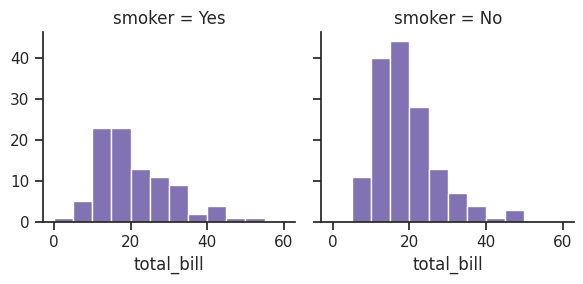

In [16]:
# Specify the order for plot elements:
g = sns.FacetGrid(tips, col="smoker", col_order=["Yes", "No"])
g = g.map(plt.hist, "total_bill", bins=bins, color="m")

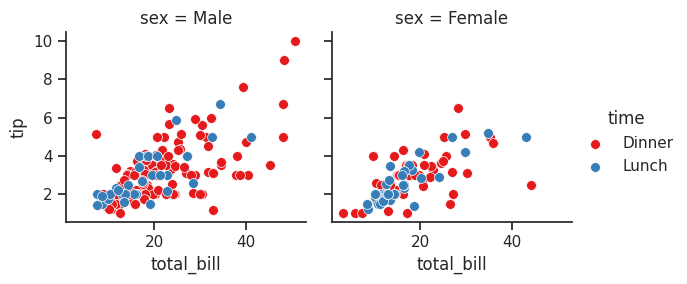

In [17]:
# Use a different color palette:
kws = dict(s=50, linewidth=.5, edgecolor="w")
g = sns.FacetGrid(tips, col="sex", hue="time",
                  palette="Set1",
                  hue_order=["Dinner", "Lunch"])
g = (g.map(plt.scatter, "total_bill", "tip", **kws).add_legend())

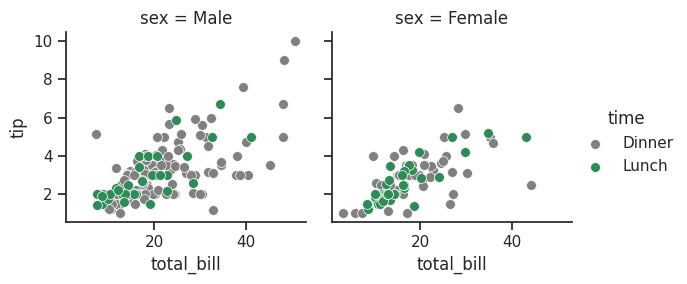

In [18]:
pal = dict(Lunch="seagreen", Dinner="gray")
g = sns.FacetGrid(tips, col="sex", hue="time",
                  palette=pal, hue_order=["Dinner", "Lunch"])
g = (g.map(plt.scatter, "total_bill", "tip", **kws).add_legend())


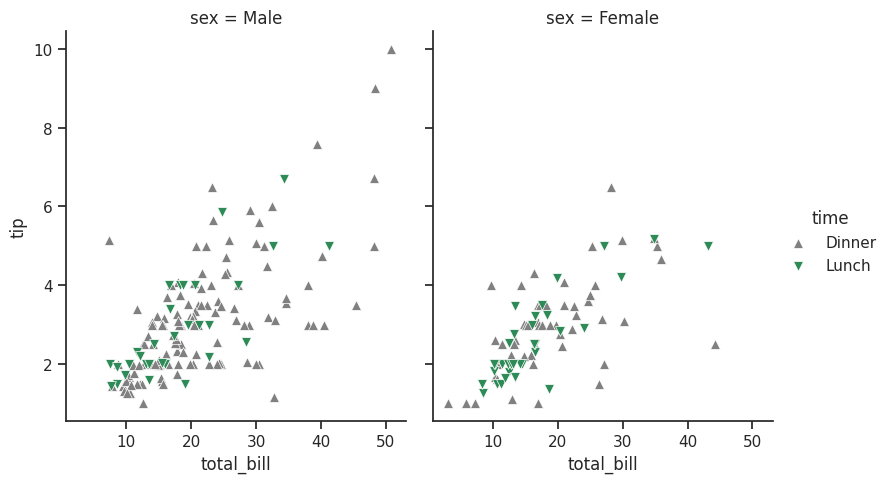

In [19]:
g = sns.FacetGrid(tips, col="sex", hue="time", palette=pal,
                hue_order=["Dinner", "Lunch"],
                hue_kws=dict(marker=["^", "v"]),
                 height=5, aspect=.8)
g=(g.map(plt.scatter, "total_bill", "tip", **kws).add_legend())


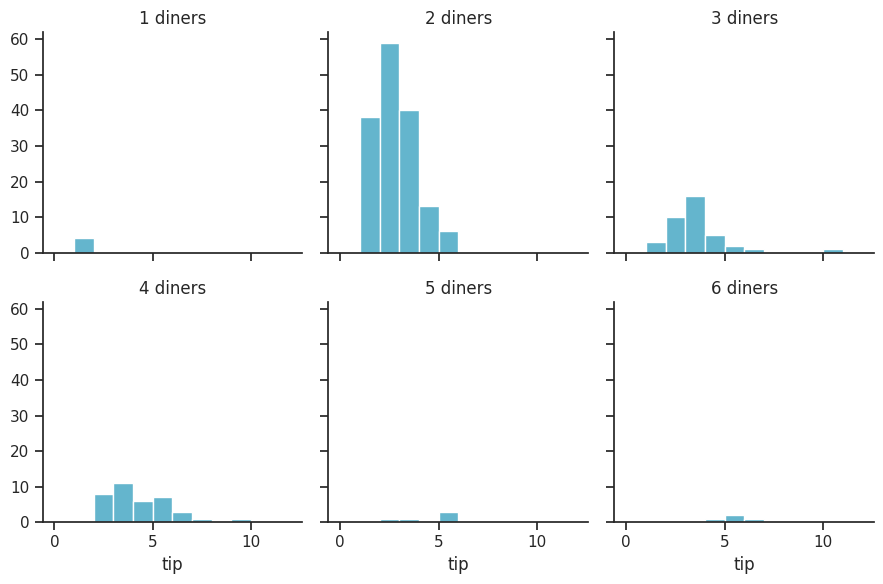

In [20]:
g = sns.FacetGrid(tips, col="size", col_wrap=3)
g = (g.map(plt.hist, "tip", bins=np.arange(0, 13), color="c")
     .set_titles("{col_name} diners"))

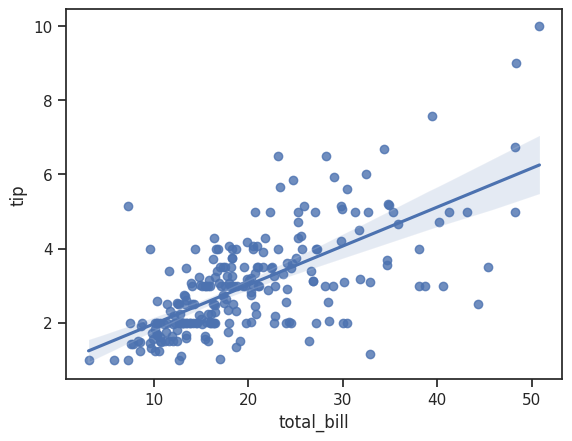

In [21]:
# linear regression models
sns.regplot(x="total_bill", y="tip", data=tips);

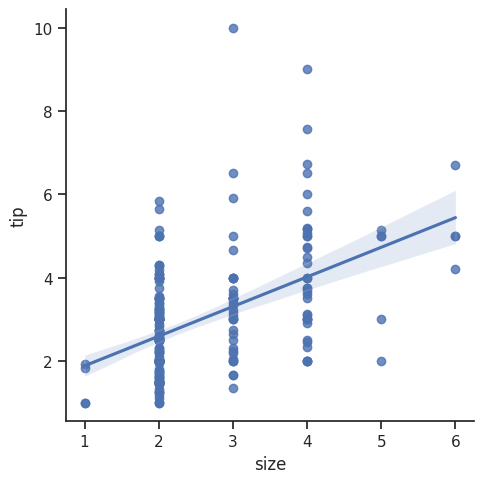

In [22]:
 #linear regression when one of the variables takes discrete values
sns.lmplot(x="size", y="tip", data=tips);

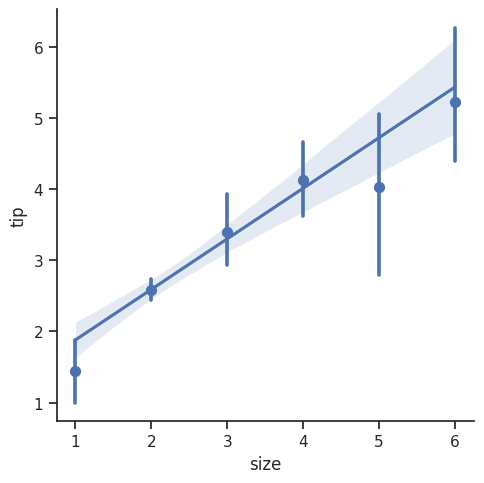

In [23]:
# observations in each discrete bin to plot an estimate of central tendency along
# with a confidence interval:
sns.lmplot(x="size", y="tip", data=tips, x_estimator=np.mean);

In [24]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


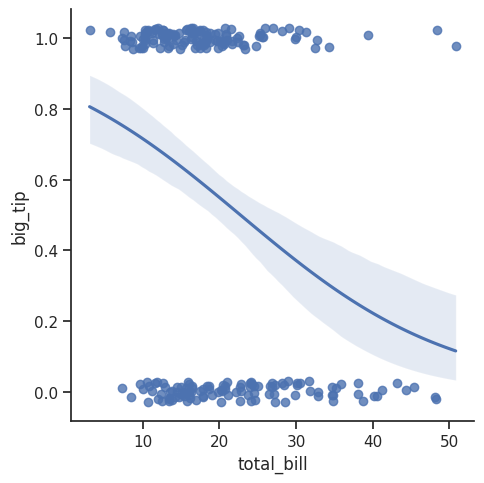

In [25]:
tips["big_tip"] = (tips.tip / tips.total_bill) > .15
sns.lmplot(x="total_bill", y="big_tip", data=tips,
           logistic=True, y_jitter=.03);

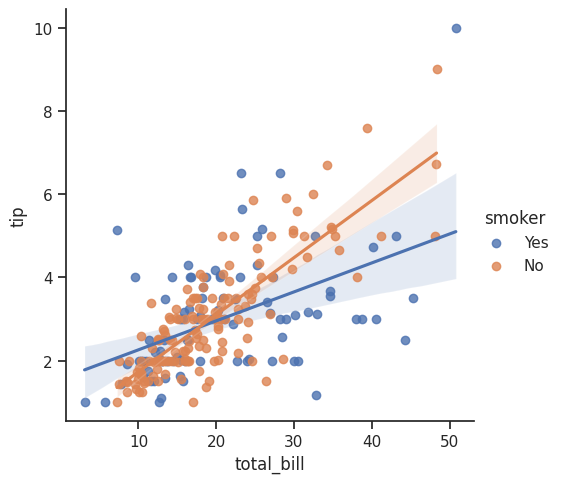

In [26]:
sns.lmplot(x="total_bill", y="tip", hue="smoker", data=tips);

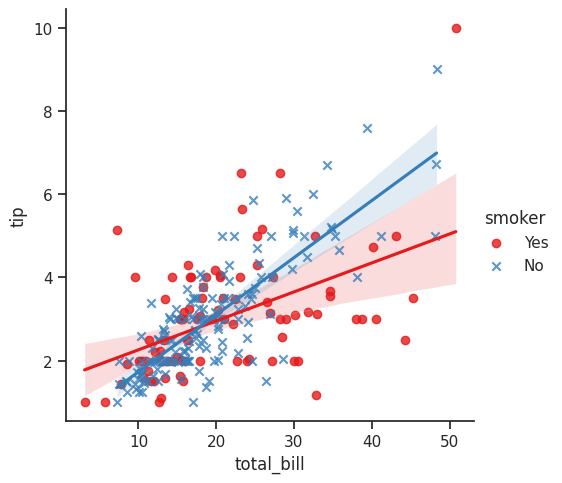

In [27]:
sns.lmplot(x="total_bill", y="tip", hue="smoker", data=tips,
           markers=["o", "x"], palette="Set1");

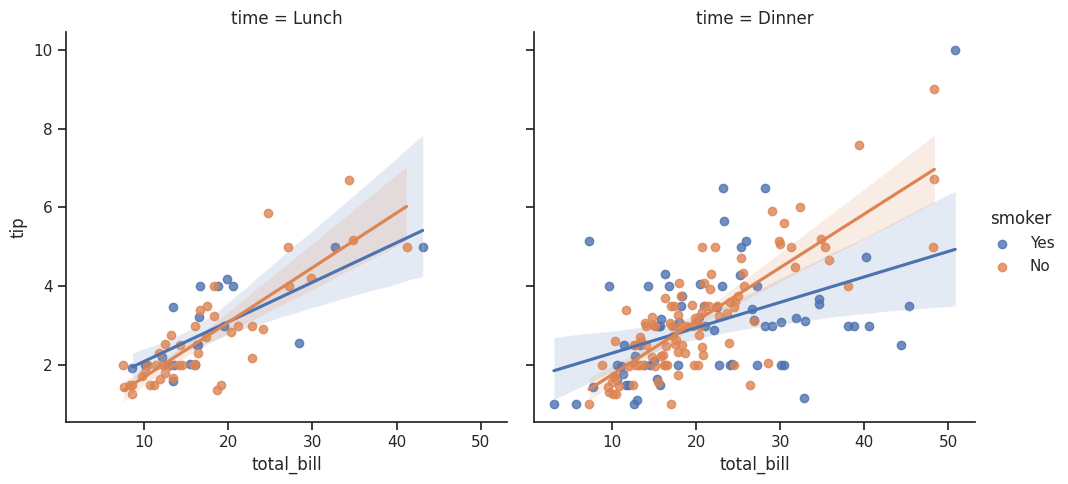

In [28]:
sns.lmplot(x="total_bill", y="tip", hue="smoker", col="time", data=tips);

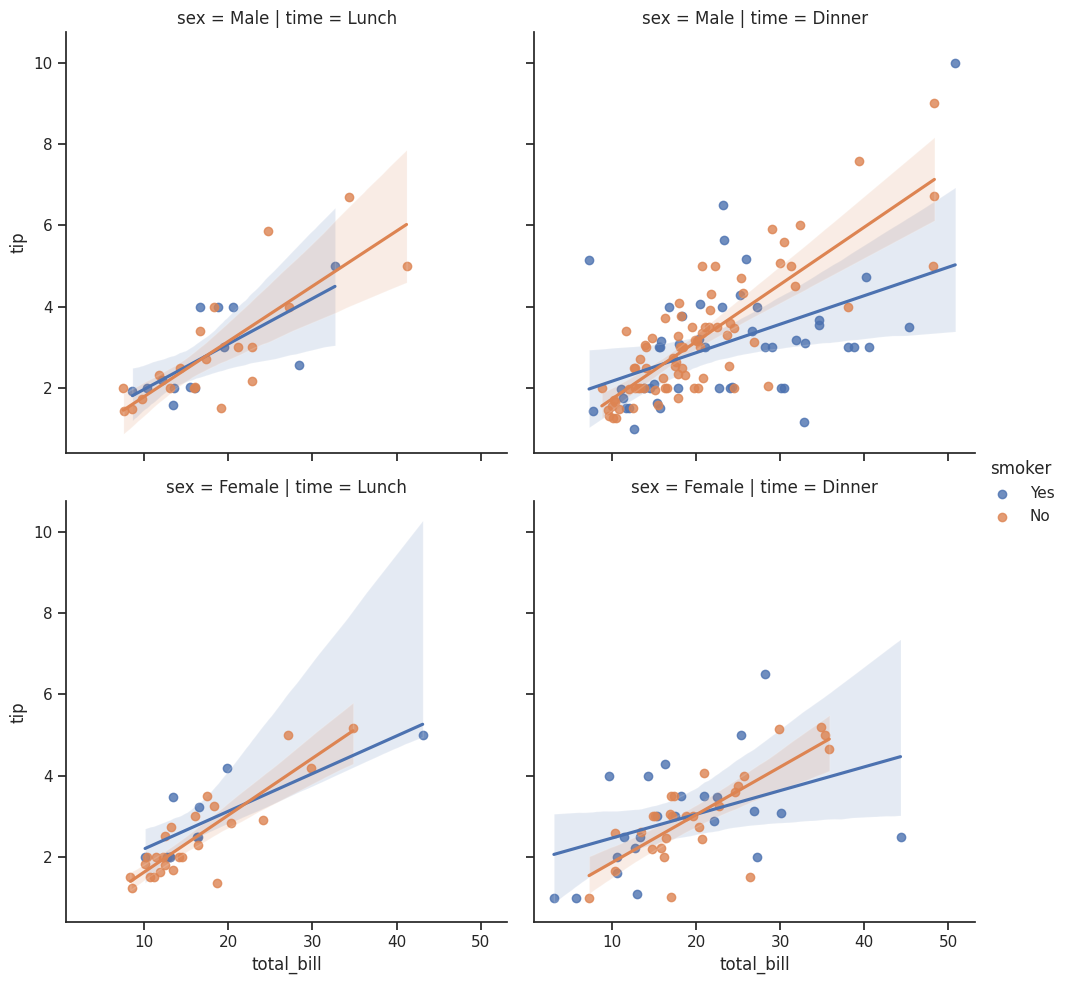

In [29]:
sns.lmplot(x="total_bill", y="tip", hue="smoker",
           col="time", row="sex", data=tips);

## Introduction Residual Plot

-The residplot() function can be a useful tool for checking whether the simple regression model is appropriate for a dataset. It fits and removes a simple linear regression and then plots the residual values for each observation. Ideally, these values should be randomly scattered around y = 0:

In [30]:

sns.residplot(x="x", y="y", data=df[df.dataset == 'I'],
              scatter_kws={"s": 80});

NameError: name 'df' is not defined

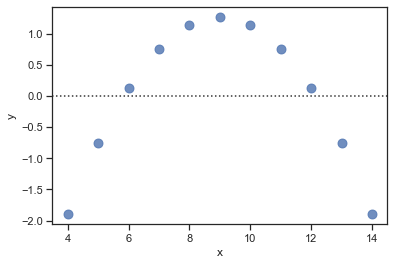

In [ ]:
sns.residplot(x="x", y="y", data=df[df.dataset == 'II'],
              scatter_kws={"s": 80});

## Seborn 4 Models fitting

In [ ]:
df = sns.load_dataset("anscombe")

In [ ]:
df.head(2)

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95


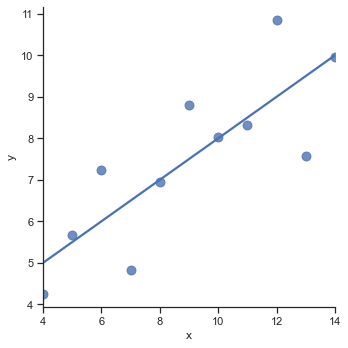

In [ ]:
sns.lmplot(x="x", y="y", data=df.query("dataset == 'I'"),
           ci=None, scatter_kws={"s": 80});
#df[df.dataset=="I"]

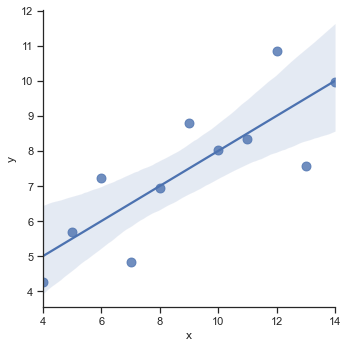

In [ ]:
sns.lmplot(x="x", y="y", data=df.query("dataset == 'I'"),
           ci=95, scatter_kws={"s": 80});
#df[df.dataset=="I"]

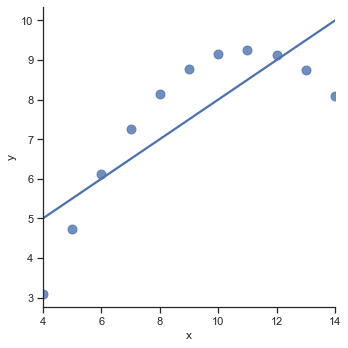

In [ ]:
sns.lmplot(x="x", y="y", data=df[df.dataset=='II'],
   ci=None, scatter_kws={"s": 80});

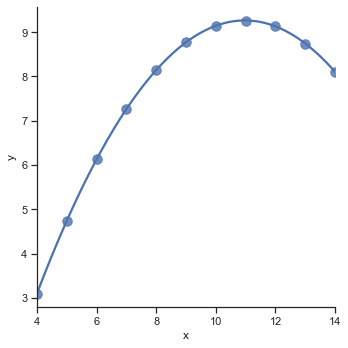

In [ ]:
sns.lmplot(x="x", y="y", data=df[df.dataset=='II'],
           order=2, ci=95, scatter_kws={"s": 90});